In [17]:
# Importar las bibliotecas necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Configurar el estilo de los gráficos
sns.set_style('whitegrid')

### Carga y Exploración de Datos
Comenzaremos cargando una muestra del dataset provisto y explorando sus características básicas para entender con qué estamos trabajando.

In [18]:
import io

# Muestra del dataset sintético de Liverpool cargado a través de un String
csv_data = """DENOMINACIÓN,Descripción,No. Reg.,Fecha,Total Sales,Revenue,Antigüedad de la Marca,Número de Leads en Web,Calificación Promedio de Productos,Número de Devoluciones,Renovó,Participación de Mercado (%),Avg Market Share
#OCTUBREROSA CUIDATE,"PRENDAS DE VESTIR, CALZADO, ARTICULOS DE SOMBRERERIA.",2048635,2019-07-31 00:00:00,37,8941.0785777531728,7,12,4.02900644475073,3,si,0.001787405381240263,0.001137124841632526
#OCTUBREROSA CUIDATE,"PRENDAS DE VESTIR, CALZADO, ARTICULOS DE SOMBRERERIA.",2048635,2019-08-31 00:00:00,39,8465.6954577281449,7,15,4.0989711727794571,1,si,0.0016988109887157521,0.001137124841632526
#OCTUBREROSA CUIDATE,"PRENDAS DE VESTIR, CALZADO, ARTICULOS DE SOMBRERERIA.",2048635,2019-09-30 00:00:00,45,9592.95148509415,7,17,4.1338379921340929,1,si,0.001903054315097269,0.001137124841632526
#OCTUBREROSA CUIDATE,"PRENDAS DE VESTIR, CALZADO, ARTICULOS DE SOMBRERERIA.",2048635,2019-10-31 00:00:00,37,7647.2016084224988,7,10,4.020307534481347,4,si,0.0015033103820814239,0.001137124841632526
#OCTUBREROSA CUIDATE,"PRENDAS DE VESTIR, CALZADO, ARTICULOS DE SOMBRERERIA.",2048635,2019-11-30 00:00:00,36,8824.5643383011666,7,9,4.071725525845781,5,si,0.0017056238350786929,0.001137124841632526
#OCTUBREROSA CUIDATE,"PRENDAS DE VESTIR, CALZADO, ARTICULOS DE SOMBRERERIA.",2048635,2019-12-31 00:00:00,48,10532.851467374139,7,14,4.4640234881859433,3,si,0.0020399839755579721,0.001137124841632526
"""

df = pd.read_csv(io.StringIO(csv_data))

# Mostrar las primeras filas del dataset
display(df.head())

# Obtener información general sobre las columnas y tipos de datos
print("\nInformación del DataFrame:")
df.info()

,DENOMINACIÓN,Descripción,No. Reg.,Fecha,Total Sales,Revenue,Antigüedad de la Marca,Número de Leads en Web,Calificación Promedio de Productos,Número de Devoluciones,Renovó,Participación de Mercado (%),Avg Market Share
0,#OCTUBREROSA CUIDATE,"PRENDAS DE VESTIR, CALZADO, ARTICULOS DE SOMBR...",2048635,2019-07-31 00:00:00,37,8941.078578,7,12,4.029006,3,si,0.001787,0.001137
1,#OCTUBREROSA CUIDATE,"PRENDAS DE VESTIR, CALZADO, ARTICULOS DE SOMBR...",2048635,2019-08-31 00:00:00,39,8465.695458,7,15,4.098971,1,si,0.001699,0.001137
2,#OCTUBREROSA CUIDATE,"PRENDAS DE VESTIR, CALZADO, ARTICULOS DE SOMBR...",2048635,2019-09-30 00:00:00,45,9592.951485,7,17,4.133838,1,si,0.001903,0.001137
3,#OCTUBREROSA CUIDATE,"PRENDAS DE VESTIR, CALZADO, ARTICULOS DE SOMBR...",2048635,2019-10-31 00:00:00,37,7647.201608,7,10,4.020308,4,si,0.001503,0.001137
4,#OCTUBREROSA CUIDATE,"PRENDAS DE VESTIR, CALZADO, ARTICULOS DE SOMBR...",2048635,2019-11-30 00:00:00,36,8824.564338,7,9,4.071726,5,si,0.001706,0.001137



,Información del DataFrame:
,<class 'pandas.core.frame.DataFrame'>
,RangeIndex: 6 entries, 0 to 5
,Data columns (total 13 columns):
, #   Column                              Non-Null Count  Dtype  
,---  ------                              --------------  -----  
, 0   DENOMINACIÓN                        6 non-null      object 
, 1   Descripción                         6 non-null      object 
, 2   No. Reg.                            6 non-null      int64  
, 3   Fecha                               6 non-null      object 
, 4   Total Sales                         6 non-null      int64  
, 5   Revenue                             6 non-null      float64
, 6   Antigüedad de la Marca              6 non-null      int64  
, 7   Número de Leads en Web              6 non-null      int64  
, 8   Calificación Promedio de Productos  6 non-null      float64
, 9   Número de Devoluciones              6 non-null      int64  
, 10  Renovó                              6 non-null      object 
, 11  Par

In [19]:
df = pd.read_excel("procesamiento_final.xlsx")
# Mostrar las primeras filas del dataset
display(df.head())

,DENOMINACIÓN,Descripción,Total Sales,Revenue,Antigüedad de la Marca,Número de Leads en Web,Calificación Promedio de Productos,Número de Devoluciones,Renovó,Participación de Mercado (%),Avg Market Share,Crecimiento Total Sales
0,#OCTUBREROSA CUIDATE,"PRENDAS DE VESTIR, CALZADO, ARTICULOS DE SOMBR...",335.125000,7.340517e+04,7,52.250000,3.254327,56.750000,si,0.001140,0.001137,-0.017314
1,#OCTUBREROSA CUIDATE,PUBLICIDAD; GESTION DE NEGOCIOS COMERCIALES; A...,321.875000,9.277497e+04,7,63.000000,3.198713,51.750000,si,0.001505,0.001479,-0.128812
2,#ZONA D,"PRENDAS DE VESTIR, CALZADO, ARTICULOS DE SOMBR...",172.000000,7.223436e+04,11,29.272727,2.327540,30.272727,no,0.001579,0.001627,-0.373398
3,#ZONA D,"PUBLICIDAD, GESTION DE NEGOCIOS COMERCIALES, A...",430.090909,7.795504e+04,11,68.000000,2.318617,76.818182,no,0.001645,0.001705,-0.333679
4,1 TO 9,"VESTUARIO CASUAL, INFORMAL, DE GALA, DEPORTIVO...",59238.466667,7.772100e+06,29,23615.400000,4.296330,3036.300000,si,0.157607,0.159221,0.224401


In [20]:
len(df)

2764

In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
,RangeIndex: 2764 entries, 0 to 2763
,Data columns (total 12 columns):
, #   Column                              Non-Null Count  Dtype  
,---  ------                              --------------  -----  
, 0   DENOMINACIÓN                        2764 non-null   object 
, 1   Descripción                         2764 non-null   object 
, 2   Total Sales                         2764 non-null   float64
, 3   Revenue                             2764 non-null   float64
, 4   Antigüedad de la Marca              2764 non-null   int64  
, 5   Número de Leads en Web              2764 non-null   float64
, 6   Calificación Promedio de Productos  2764 non-null   float64
, 7   Número de Devoluciones              2764 non-null   float64
, 8   Renovó                              2764 non-null   object 
, 9   Participación de Mercado (%)        2764 non-null   float64
, 10  Avg Market Share                    2764 non-null   float64
, 11  Crecimiento Total Sales    

### Preprocesamiento de Datos
Antes de entrenar los modelos necesitamos:
1. Seleccionar las características principales (*features*) y lo que queremos predecir (*target*).
2. Convertir los valores de texto de la columna a predecir (`si`/`no`) en valores binarios (`1`/`0`).
3. Dividir el conjunto total en un grupo de **entrenamiento** (para que los modelos aprendan) y otro grupo de **prueba** (para medir qué tan bien aprendieron).

In [22]:
# 1. Separar características (X) y la variable objetivo (y)
features = ['Avg Market Share', 'Revenue', 'Antigüedad de la Marca', 'Calificación Promedio de Productos', 'Participación de Mercado (%)','Crecimiento Total Sales']
target = 'Renovó'

X = df[features]
y = df[target]

# 2. Mapear la variable objetivo a valores numéricos (si=1, no=0)
y = y.map({'si': 1, 'no': 0})

# 3. Dividir los datos en conjuntos de entrenamiento y prueba (70% entrenamiento, 30% prueba)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print(f"Tamaño del conjunto de entrenamiento (X_train): {X_train.shape}")
print(f"Tamaño del conjunto de prueba (X_test): {X_test.shape}")

Tamaño del conjunto de entrenamiento (X_train): (1934, 6)
,Tamaño del conjunto de prueba (X_test): (830, 6)


### Modelo 1: Árbol de Decisión
Un árbol de decisión es un modelo predictivo que toma decisiones basándose en una serie de preguntas condicionales sobre los datos. Es fácil de entender e interpretar, pero puede sufrir de *overfitting* (sobreajuste), lo que significa que memoriza los datos de entrenamiento pero se equivoca con datos nuevos.

In [23]:
import numpy as np
from sklearn.tree import DecisionTreeClassifier
# Inicializar y entrenar el modelo de Árbol de Decisión
# Ajustar hiperparámetros como max_depth, min_samples_leaf, min_samples_split y class_weight para prevenir sobreajuste y mejorar la generalización
# Ajustando max_depth para permitir más complejidad, y min_samples_leaf/min_samples_split para permitir hojas más pequeñas y splits más específicos.
decision_tree_model = DecisionTreeClassifier(random_state=3002, class_weight='balanced') # Removed max_depth, min_samples_leaf, min_samples_split to allow full growth
decision_tree_model.fit(X_train, y_train)

# Realizar predicciones usando los datos reservados para prueba
y_pred_dt = decision_tree_model.predict(X_test)

#### Evaluación del Árbol de Decisión
Generamos un reporte con métricas clave y una Matriz de Confusión para visualizar en qué clases acierta y en cuáles se equivoca.

--- Métricas de Árbol de Decisión ---
,              precision    recall  f1-score   support
,
,           0       0.96      0.97      0.96       229
,           1       0.99      0.99      0.99       601
,
,    accuracy                           0.98       830
,   macro avg       0.97      0.98      0.97       830
,weighted avg       0.98      0.98      0.98       830
,
,Especificidad: 0.97


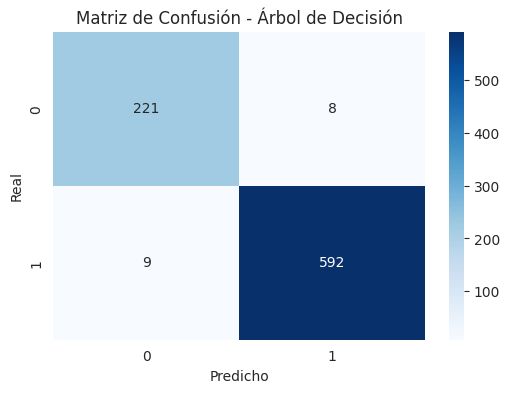


,Primeras 5 probabilidades de predicción para el Árbol de Decisión (Clase 0, Clase 1):


,Probabilidad_0,Probabilidad_1
0,0.0,1.0
1,1.0,0.0
2,1.0,0.0
3,0.0,1.0
4,0.0,1.0


In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

print("--- Métricas de Árbol de Decisión ---")
print(classification_report(y_test, y_pred_dt))

# Creación de la Matriz de Confusión
cm_dt = confusion_matrix(y_test, y_pred_dt)
tn, fp, fn, tp = cm_dt.ravel()
specificity_dt = tn / (tn + fp)
print(f"Especificidad: {specificity_dt:.2f}")
plt.figure(figsize=(6, 4))
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusión - Árbol de Decisión')
plt.xlabel('Predicho')
plt.ylabel('Real')
plt.show()

# Obtener las probabilidades de predicción
y_pred_proba_dt = decision_tree_model.predict_proba(X_test)
print("\nPrimeras 5 probabilidades de predicción para el Árbol de Decisión (Clase 0, Clase 1):")
display(pd.DataFrame(y_pred_proba_dt, columns=['Probabilidad_0', 'Probabilidad_1']).head())

### Modelo 1.1: Árbol de Decisión con SMOTE

Dado que la especificidad sigue siendo un problema y se mencionó la posibilidad de desbalance de clases, aplicaremos la técnica de sobremuestreo **SMOTE (Synthetic Minority Over-sampling Technique)** a los datos de entrenamiento. SMOTE crea nuevas muestras sintéticas de la clase minoritaria, lo que puede ayudar al modelo a aprender mejor las características de esta clase y mejorar su rendimiento en la detección de la clase minoritaria (en este caso, la clase 'no renovó').

In [25]:
from imblearn.over_sampling import SMOTE
from collections import Counter
from sklearn.tree import DecisionTreeClassifier

print(f'Distribución de clases antes de SMOTE: {Counter(y_train)}')

sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)
print(f'Distribución de clases después de SMOTE: {Counter(y_train_res)}')

# Inicializar y entrenar el modelo de Árbol de Decisión con los datos re-balanceados por SMOTE
# Sin hiperparámetros restrictivos para permitir que el árbol crezca completamente, pero con class_weight='balanced'
decision_tree_model_smote = DecisionTreeClassifier(random_state=42, class_weight='balanced')
decision_tree_model_smote.fit(X_train_res, y_train_res)

# Realizar predicciones usando el modelo recién entrenado
y_pred_dt_smote = decision_tree_model_smote.predict(X_test)
print("Modelo de Árbol de Decisión con SMOTE reentrenado y predicciones actualizadas.")

Distribución de clases antes de SMOTE: Counter({1: 1403, 0: 531})
,Distribución de clases después de SMOTE: Counter({1: 1403, 0: 1403})
,Modelo de Árbol de Decisión con SMOTE reentrenado y predicciones actualizadas.


#### Evaluación del Árbol de Decisión con SMOTE

--- Métricas de Árbol de Decisión con SMOTE ---
,              precision    recall  f1-score   support
,
,           0       0.94      0.98      0.96       229
,           1       0.99      0.98      0.98       601
,
,    accuracy                           0.98       830
,   macro avg       0.97      0.98      0.97       830
,weighted avg       0.98      0.98      0.98       830
,
,Especificidad con SMOTE: 0.98


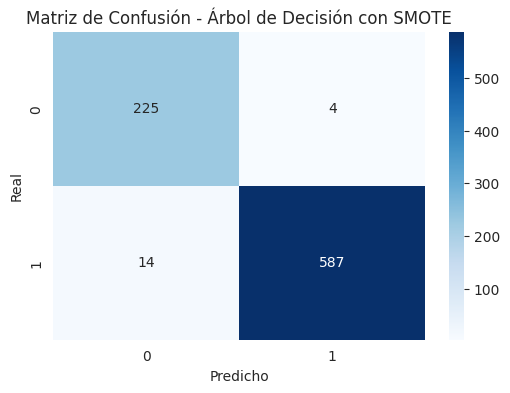


,Primeras 5 probabilidades de predicción para el Árbol de Decisión con SMOTE (Clase 0, Clase 1):


,Probabilidad_0,Probabilidad_1
0,0.0,1.0
1,1.0,0.0
2,1.0,0.0
3,0.0,1.0
4,0.0,1.0


In [26]:
print("--- Métricas de Árbol de Decisión con SMOTE ---")
print(classification_report(y_test, y_pred_dt_smote))

# Creación de la Matriz de Confusión
cm_dt_smote = confusion_matrix(y_test, y_pred_dt_smote)
tn_smote, fp_smote, fn_smote, tp_smote = cm_dt_smote.ravel()
specificity_dt_smote = tn_smote / (tn_smote + fp_smote)
print(f"Especificidad con SMOTE: {specificity_dt_smote:.2f}")
plt.figure(figsize=(6, 4))
sns.heatmap(cm_dt_smote, annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusión - Árbol de Decisión con SMOTE')
plt.xlabel('Predicho')
plt.ylabel('Real')
plt.show()

# Obtener las probabilidades de predicción
y_pred_proba_dt_smote = decision_tree_model_smote.predict_proba(X_test)
print("\nPrimeras 5 probabilidades de predicción para el Árbol de Decisión con SMOTE (Clase 0, Clase 1):")
display(pd.DataFrame(y_pred_proba_dt_smote, columns=['Probabilidad_0', 'Probabilidad_1']).head())

### Persistencia del Modelo
Para evitar reentrenar el modelo cada vez que necesitemos usarlo, podemos guardarlo en un archivo utilizando la biblioteca `joblib`. Esto permite exportar el modelo entrenado y cargarlo posteriormente en este o en otros entornos.

In [27]:
y_pred = decision_tree_model.predict(df[features][0:3])

In [28]:
import joblib

# Guardar el modelo Random Forest (o el de tu elección)
filename = 'decision_tree_model.joblib'
joblib.dump(decision_tree_model, filename)
print(f"Modelo '{filename}' guardado exitosamente.")

Modelo 'decision_tree_model.joblib' guardado exitosamente.


In [29]:
import joblib

# Guardar el modelo Random Forest (o el de tu elección)
filename = 'decision_tree_model.joblib'
joblib.dump(decision_tree_model, filename)
print(f"Modelo '{filename}' guardado exitosamente.")

# Cargar el modelo guardado
loaded_model = joblib.load(filename)
print(f"Modelo '{filename}' cargado exitosamente.")

# Demostrar que el modelo cargado puede hacer predicciones
y_pred_loaded = loaded_model.predict(df[features][0:3])
print("\nPredicciones con el modelo cargado (Decision Tree):")
print(y_pred_loaded)

# Comparar con las predicciones originales del modelo Random Forest
import numpy as np
print("¿Las predicciones del modelo cargado son idénticas a las originales?", np.array_equal(y_pred, y_pred_loaded))

Modelo 'decision_tree_model.joblib' guardado exitosamente.
,Modelo 'decision_tree_model.joblib' cargado exitosamente.
,
,Predicciones con el modelo cargado (Decision Tree):
,[1 1 0]
,¿Las predicciones del modelo cargado son idénticas a las originales? True


In [30]:
registro_marca = {'Revenue': 8941.078577753173, 'Antigüedad de la Marca': 7.0, 'Avg Market Share': 8.528, 'Calificación Promedio de Productos': 4.02900644475073, 'Participación de Mercado (%)': 60.0,'Crecimiento Total Sales': 0.232801850175774}
predicción = loaded_model.predict(np.array(list(registro_marca.values())).reshape(1, -1))
print(registro_marca)
print(predicción)

{'Revenue': 8941.078577753173, 'Antigüedad de la Marca': 7.0, 'Avg Market Share': 8.528, 'Calificación Promedio de Productos': 4.02900644475073, 'Participación de Mercado (%)': 60.0, 'Crecimiento Total Sales': 0.232801850175774}
,[1]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
,  warnings.warn(


In [31]:
def predict_batch(new_data_list, model, feature_names):
    new_data_df = pd.DataFrame(new_data_list, columns=feature_names)

    predictions = model.predict(new_data_df)

    return predictions

new_records = [
    # Primer registro
    {'Revenue': 8941.078577753173, 'Antigüedad de la Marca': 7.0, 'Avg Market Share': 0.001787405381240263, 'Calificación Promedio de Productos': 4.02900644475073, 'Participación de Mercado (%)': 0.001137124841632526, 'Crecimiento Total Sales': 0.232801850175774},
    # Segundo registro
    {'Revenue': 15000.0, 'Antigüedad de la Marca': 10.0, 'Avg Market Share': 0.002, 'Calificación Promedio de Productos': 4.5, 'Participación de Mercado (%)': 0.0015, 'Crecimiento Total Sales': 0.232801850175774},
    # Tercer registro
    {'Revenue': 5000.0, 'Antigüedad de la Marca': 2.0, 'Avg Market Share': 0.0005, 'Calificación Promedio de Productos': 3.0, 'Participación de Mercado (%)': 0.0003, 'Crecimiento Total Sales': 0.232801850175774}
]


batch_predictions = predict_batch(new_records, loaded_model, features)

print("\nNuevos registros para predicción:")
for i, record in enumerate(new_records):
    print(f"Registro {i+1}: {record}")

print("\nPredicciones en batch (1 = Renovó, 0 = No Renovó):")
print(batch_predictions)


,Nuevos registros para predicción:
,Registro 1: {'Revenue': 8941.078577753173, 'Antigüedad de la Marca': 7.0, 'Avg Market Share': 0.001787405381240263, 'Calificación Promedio de Productos': 4.02900644475073, 'Participación de Mercado (%)': 0.001137124841632526, 'Crecimiento Total Sales': 0.232801850175774}
,Registro 2: {'Revenue': 15000.0, 'Antigüedad de la Marca': 10.0, 'Avg Market Share': 0.002, 'Calificación Promedio de Productos': 4.5, 'Participación de Mercado (%)': 0.0015, 'Crecimiento Total Sales': 0.232801850175774}
,Registro 3: {'Revenue': 5000.0, 'Antigüedad de la Marca': 2.0, 'Avg Market Share': 0.0005, 'Calificación Promedio de Productos': 3.0, 'Participación de Mercado (%)': 0.0003, 'Crecimiento Total Sales': 0.232801850175774}
,
,Predicciones en batch (1 = Renovó, 0 = No Renovó):
,[1 1 1]


In [32]:
import pandas as pd

# Cargar el archivo Excel 'Set de prueba Batch.xlsx'
batch_df = pd.read_excel('Set para Batch NUEVO.xlsx')

print("Datos cargados desde 'Set para Batch NUEVO.xlsx':")
display(batch_df.head())

# Extraer las características del DataFrame para la predicción
# Asegúrate de que las columnas coincidan con las características usadas para entrenar el modelo
new_data_for_batch_prediction = batch_df[features]

# Realizar predicciones en batch con el modelo cargado
batch_predictions_excel = loaded_model.predict(new_data_for_batch_prediction)

print("\nPredicciones en batch para los datos del Excel (1 = Renovó, 0 = No Renovó):")
print(batch_predictions_excel)

# Opcional: Añadir las predicciones al DataFrame original para visualización
batch_df['Predicción_Renovación'] = batch_predictions_excel
display(batch_df.head())

Datos cargados desde 'Set para Batch NUEVO.xlsx':


,DENOMINACIÓN,Revenue,Antigüedad de la Marca,Calificación Promedio de Productos,Participación de Mercado (%),Avg Market Share,Crecimiento Total Sales
0,#OCTUBREROSA CUIDATE,7.340517e+04,7,3.254327,0.001140,0.001137,-0.017314
1,#OCTUBREROSA CUIDATE,9.277497e+04,7,3.198713,0.001505,0.001479,-0.128812
2,#ZONA D,7.223436e+04,11,2.327540,0.001579,0.001627,-0.373398
3,#ZONA D,7.795504e+04,11,2.318617,0.001645,0.001705,-0.333679
4,1 TO 9,7.772100e+06,29,4.296330,0.157607,0.159221,0.224401



,Predicciones en batch para los datos del Excel (1 = Renovó, 0 = No Renovó):
,[1 1 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]


,DENOMINACIÓN,Revenue,Antigüedad de la Marca,Calificación Promedio de Productos,Participación de Mercado (%),Avg Market Share,Crecimiento Total Sales,Predicción_Renovación
0,#OCTUBREROSA CUIDATE,7.340517e+04,7,3.254327,0.001140,0.001137,-0.017314,1
1,#OCTUBREROSA CUIDATE,9.277497e+04,7,3.198713,0.001505,0.001479,-0.128812,1
2,#ZONA D,7.223436e+04,11,2.327540,0.001579,0.001627,-0.373398,0
3,#ZONA D,7.795504e+04,11,2.318617,0.001645,0.001705,-0.333679,0
4,1 TO 9,7.772100e+06,29,4.296330,0.157607,0.159221,0.224401,1


In [33]:
from google.colab import files

files.download('decision_tree_model.joblib')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>